<a href="https://colab.research.google.com/github/ibrahimsaqib-ai/Introduction-to-AI-Labs/blob/main/Lab-03/Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define your exact file path
file_path = '/content/drive/MyDrive/dataset/house_price_regression_dataset.csv'

# 3. Read into DataFrame and preview
df = pd.read_csv(file_path)
df.head()

Mounted at /content/drive


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# X aur y ko columns ke mutabic set karna
X = df[['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']]
y = df['House_Price']

# Model ko train karna
model = LinearRegression()
model.fit(X, y)

# Slopes aur Constant check karna
print("Slopes (Coefficients):", model.coef_)
print("Constant (Intercept):", model.intercept_)


Slopes (Coefficients): [  199.75641134 10170.95455688  8244.53504421   991.46815325
 14919.32317964  5158.06376074    80.61739988]
Constant (Intercept): -2006987.6500854841


In [ ]:
from sklearn.model_selection import train_test_split
X=df[['YearsExperience']]
y=df['Salary']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_test


,YearsExperience
27,9.7
15,5.0
23,8.3
17,5.4
8,3.3
9,3.8


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_predict = model.predict(X_test)
y_predict

array([115791.21011287,  71499.27809463, 102597.86866063,  75268.80422384,
        55478.79204548,  60190.69970699])

In [ ]:
results = pd.DataFrame({
    'YearsExperience': X_test['YearsExperience'].values,
    'Actual Salary': y_test.values,
    'Predicted Salary': y_predict
})
print(results)

   YearsExperience  Actual Salary  Predicted Salary
0              9.7         112636     115791.210113
1              5.0          67939      71499.278095
2              8.3         113813     102597.868661
3              5.4          83089      75268.804224
4              3.3          64446      55478.792045
5              3.8          57190      60190.699707


In [ ]:
slope = model.coef_[0]
intercept = model.intercept_

In [ ]:
slope

np.float64(9423.815323030976)

In [ ]:
intercept

np.float64(24380.201479473704)

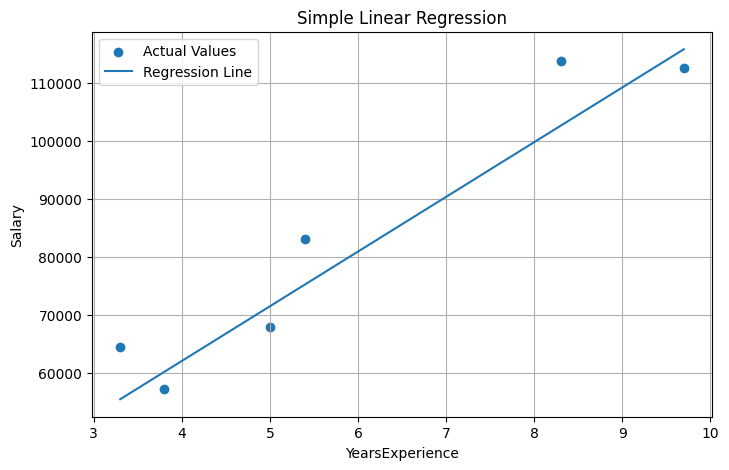

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test["YearsExperience"],
    y_test,
    label="Actual Values"
)

sorted_indices = np.argsort(X_test["YearsExperience"].values)

X_sorted = X_test["YearsExperience"].values[sorted_indices]
y_pred_sorted = y_predict[sorted_indices]

plt.plot(
    X_sorted,
    y_pred_sorted,
    label="Regression Line"
)

plt.title("Simple Linear Regression")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.legend()
plt.grid(True)

plt.show()